## Бизнес-задача

Рассеянный склероз (РС) — это хроническое заболевание центральной нервной системы, которое часто начинается с клинически изолированного синдрома (CIS). Однако не у всех пациентов с CIS развивается РС.
Цель задачи: создать модель, которая по клиническим и диагностическим признакам пациента (например, результаты МРТ, тип первых симптомов, пол, возраст) прогнозирует, перейдёт ли CIS в рассеянный склероз (CDMS - Clinically Definite Multiple Sclerosis).

Это поможет врачам:

- заранее выявлять пациентов с высоким риском развития РС;

- принимать более обоснованные решения о начале терапии;

- улучшить качество жизни пациентов за счёт ранней диагностики и профилактики.

## ML-задача

Тип задачи: бинарная классификация

Целевая переменная: Group

1 — CDMS (болезнь развилась)

2 — non-CDMS (болезнь не развилась)

Необходимо обучить модель, которая по набору признаков (возраст, пол, результаты МРТ, тип начальных симптомов и т.д.) предсказывает, принадлежит ли пациент к группе риска развития клинически определенного рассеянного склероза.

## Описание датасета

Используемый датасет:
Conversion Predictors of CIS to Multiple Sclerosis (https://www.kaggle.com/datasets/desalegngeb/conversion-predictors-of-cis-to-multiple-sclerosis)

Количество наблюдений и признаков:  примерно ~200 пациентов с множеством клинических и диагностических характеристик.

Основные признаки:

- Демографические данные: Age, Gender, Schooling

- Медицинские факторы: Breastfeeding, Varicella, Initial_Symptoms, Mono_or_Polysymptomatic

- Диагностические тесты: Oligoclonal_Bands, LLSSEP, ULSSEP, VEP, BAEP

- Результаты МРТ: Periventricular_MRI, Cortical_MRI, Infratentorial_MRI, Spinal_Cord_MRI

- Баллы EDSS (начальные и финальные)

Целевая переменная: Group (1 = CDMS, 2 = non-CDMS)

Источник данных: Когортное исследование пациентов с клинически изолированным симптомом, проводимое в Наицональном Институте Неврологии и Нейрохирургии в Мехико, Мексика, проводимое в 2006-2010 гг.

| Признак              | Определение                                                                                                     |
| -------------------- | --------------------------------------------------------------------------------------------------------------- |
| Varicella            | Ветряная оспа — вирусное заболевание; информация о перенесенной инфекции может быть связана с иммунным статусом |
| BAEP                 | Brainstem Auditory Evoked Potentials — реакция мозга на аудиостимулы, оценивает функцию слухового пути          |
| VEP                  | Visual Evoked Potential — реакция на световой или паттерн-стимул, оценивает повреждение зрительного пути        |
| Oligoclonal_Bands    | Иммуноглобулиновые полосы в CSF или крови, присутствуют у >95% пациентов с CDMS                                 |
| SSEP (ULSSEP/LLSSEP) | Somatosensory Evoked Potentials — реакция ЦНС на стимуляцию периферических нервов верхних/нижних конечностей    |
| EDSS                                                                   | Expanded Disability Status Scale — шкала инвалидизации при РС, оценивает тяжесть симптомов                      |
| Periventricular/Cortical/Infratentorial/Spinal_Cord MRI                |Наличие очагов поражения на МРТ в соответствующих отделах мозга|

## Метрики
| Метрика                       | Обоснование                                               |
| ----------------------------- | --------------------------------------------------------- |
| **F1**                  | баланс между точностью и полнотой, оптимален для медицинских данных, данные почти сбалансированы, но в данном случае FN гораздо хуже, чем FP |
| **Recall**        | минимизирует риск пропустить пациента с CDMS, False Negative критически важен, так как в таком случае есть риск пропустить заболевание и дать ему развиться              |
| **Precision** | контроль над False Positive, не "пугаем" здоровых пациентов лишний раз |
| **ROC-AUC**                  | оценка общей способности модели различать классы          |
| **Confusion Matrix**            | анализ типов ошибок модели                                |


In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [63]:
df = pd.read_csv('conversion_predictors_of_clinically_isolated_syndrome_to_multiple_sclerosis.csv', index_col = [0])

In [67]:
print("Информация о данных:")
print(df.info())

print("Первые строки датасета:")
print(df.head())

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
Index: 273 entries, 0 to 272
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   273 non-null    int64  
 1   Age                      273 non-null    int64  
 2   Schooling                272 non-null    float64
 3   Breastfeeding            273 non-null    int64  
 4   Varicella                273 non-null    int64  
 5   Initial_Symptom          272 non-null    float64
 6   Mono_or_Polysymptomatic  273 non-null    int64  
 7   Oligoclonal_Bands        273 non-null    int64  
 8   LLSSEP                   273 non-null    int64  
 9   ULSSEP                   273 non-null    int64  
 10  VEP                      273 non-null    int64  
 11  BAEP                     273 non-null    int64  
 12  Periventricular_MRI      273 non-null    int64  
 13  Cortical_MRI             273 non-null    int64  
 14  Infratento

In [69]:
print("Количество пропусков в каждом признаке:")
print(df.isnull().sum())

print("Основные статистики числовых признаков:")
print(df.describe())

Количество пропусков в каждом признаке:
Gender                       0
Age                          0
Schooling                    1
Breastfeeding                0
Varicella                    0
Initial_Symptom              1
Mono_or_Polysymptomatic      0
Oligoclonal_Bands            0
LLSSEP                       0
ULSSEP                       0
VEP                          0
BAEP                         0
Periventricular_MRI          0
Cortical_MRI                 0
Infratentorial_MRI           0
Spinal_Cord_MRI              0
Initial_EDSS               148
Final_EDSS                 148
group                        0
dtype: int64
Основные статистики числовых признаков:
           Gender         Age   Schooling  Breastfeeding   Varicella  \
count  273.000000  273.000000  272.000000     273.000000  273.000000   
mean     1.615385   34.062271   15.176471       1.831502    1.710623   
std      0.487398   11.114369    4.244175       0.874998    0.732991   
min      1.000000   15.000000 

Наблюдаются пропуски в признаках Initial_EDSS и Final_EDSS: более половины значений отсутствует.
Такие признаки, скорее всего, придетс исключить..
Остальные признаки имеют незначительное число пропусков, их можно заполнить модой или медианой.

C:\Users\drser\AppData\Local\Temp\ipykernel_1664\324287723.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='group', data=df, palette='coolwarm')


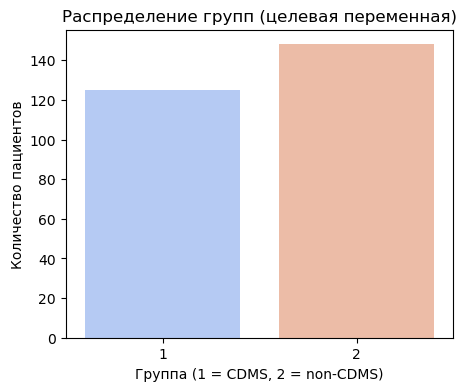

Баланс классов:
group
2    54.212454
1    45.787546
Name: proportion, dtype: float64 



In [74]:
plt.figure(figsize=(5,4))
sns.countplot(x='group', data=df, palette='coolwarm')
plt.title("Распределение групп (целевая переменная)")
plt.xlabel("Группа (1 = CDMS, 2 = non-CDMS)")
plt.ylabel("Количество пациентов")
plt.show()

print("Баланс классов:")
print(df['group'].value_counts(normalize=True) * 100, "\n")

Весьма сбалансированно, чуть-чуть больше здоровых пациентов. Можно использовать метрики без существенных перекосов.

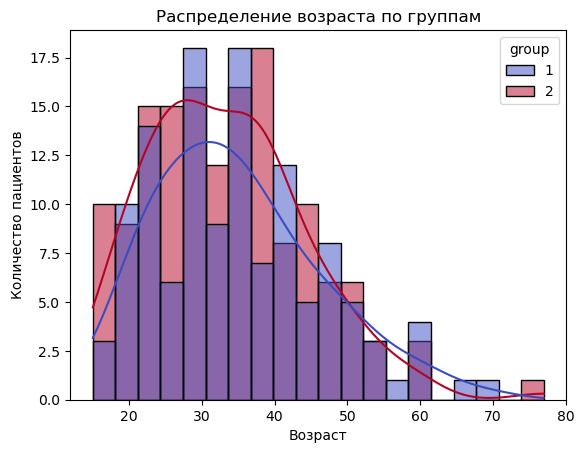

In [77]:
plt.figure()
sns.histplot(df, x="Age", hue="group", bins=20, kde=True, palette="coolwarm")
plt.title("Распределение возраста по группам")
plt.xlabel("Возраст")
plt.ylabel("Количество пациентов")
plt.show()

Возраст вряд ли является ключевым фактором, все примерно похоже. Распределение около нормальное, может быть интересно исследовать влияние возраста на переход в CDMS в будущем при наличии дополнительных данных.

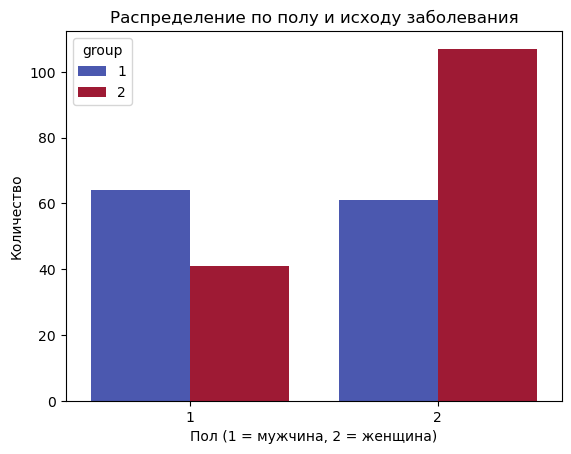

In [80]:
plt.figure()
sns.countplot(data=df, x="Gender", hue="group", palette="coolwarm")
plt.title("Распределение по полу и исходу заболевания")
plt.xlabel("Пол (1 = мужчина, 2 = женщина)")
plt.ylabel("Количество")
plt.show()

В группе с обнаруженным РС бОльшая доля женщин, что согласуется с известными клиническими данными. Среди больных РС больше женщин.

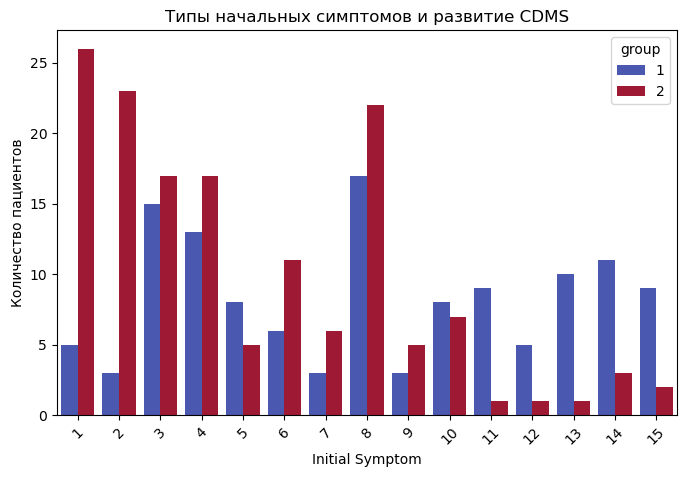

In [91]:
df['Initial_Symptom'] = pd.to_numeric(df['Initial_Symptom'], errors='coerce').astype('Int64') #Перевел в численные просто для красоты.
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Initial_Symptom", hue="group", palette="coolwarm")
plt.title("Типы начальных симптомов и развитие CDMS")
plt.xlabel("Initial Symptom")
plt.ylabel("Количество пациентов")
plt.xticks(rotation=45)
plt.show()

Initial_Symptoms - изначальные проявления
- 1 - зрительные,
- 2 - сенсорные,
- 3 - двигательные,
- 4 - другие,
- 5 - зрительные и сенсорные,
- 6 - зрительные и двигательные,
- 7 - зрительные и другие,
- 8 - сенсорные и двигательные,
- 9 - сенсорные и другие,
- 10 - двигательные и другие,
- 11 - зрительные, сенсорные и двигательные,
- 12 - зрительные, сенсорные и другие,
- 13 - зрительные, двигательные и другие,
- 14 - сенсорные, двигательные и другие,
- 15 - все четыре

Как видно, множественные типы симптомов при дебюте могут быть предиктором более тяжёлого исхода

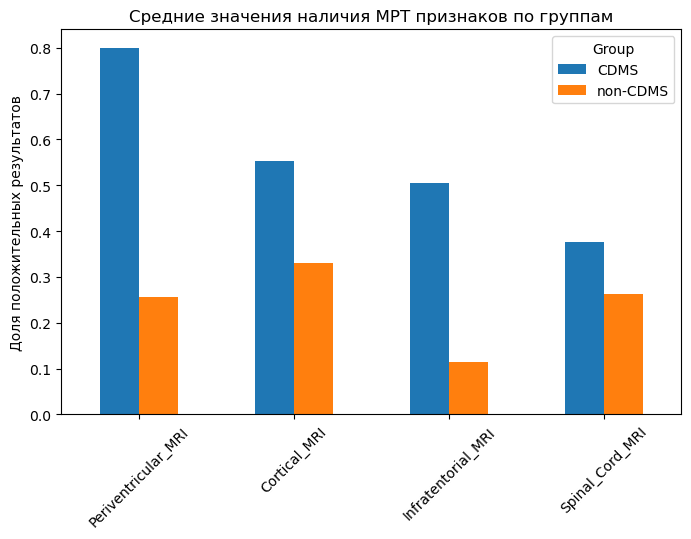

In [100]:
mri_cols = ['Periventricular_MRI', 'Cortical_MRI', 'Infratentorial_MRI', 'Spinal_Cord_MRI']
mri_means = df.groupby("group")[mri_cols].mean().T

mri_means.plot(kind="bar", figsize=(8,5))
plt.title("Средние значения наличия МРТ признаков по группам")
plt.ylabel("Доля положительных результатов")
plt.xticks(rotation=45)
plt.legend(["CDMS", "non-CDMS"], title="Group")
plt.show()

In [105]:
df.groupby(['Periventricular_MRI','Infratentorial_MRI','Cortical_MRI', 'Spinal_Cord_MRI'])['group'].value_counts(normalize=True).mul(100).to_frame(name='Доля в группе (%)').style.background_gradient(cmap='Blues')

Наиболее информативным фактором является Periventricular_MRI, отражающий наличие очагов в перивентрикулярной области мозга.

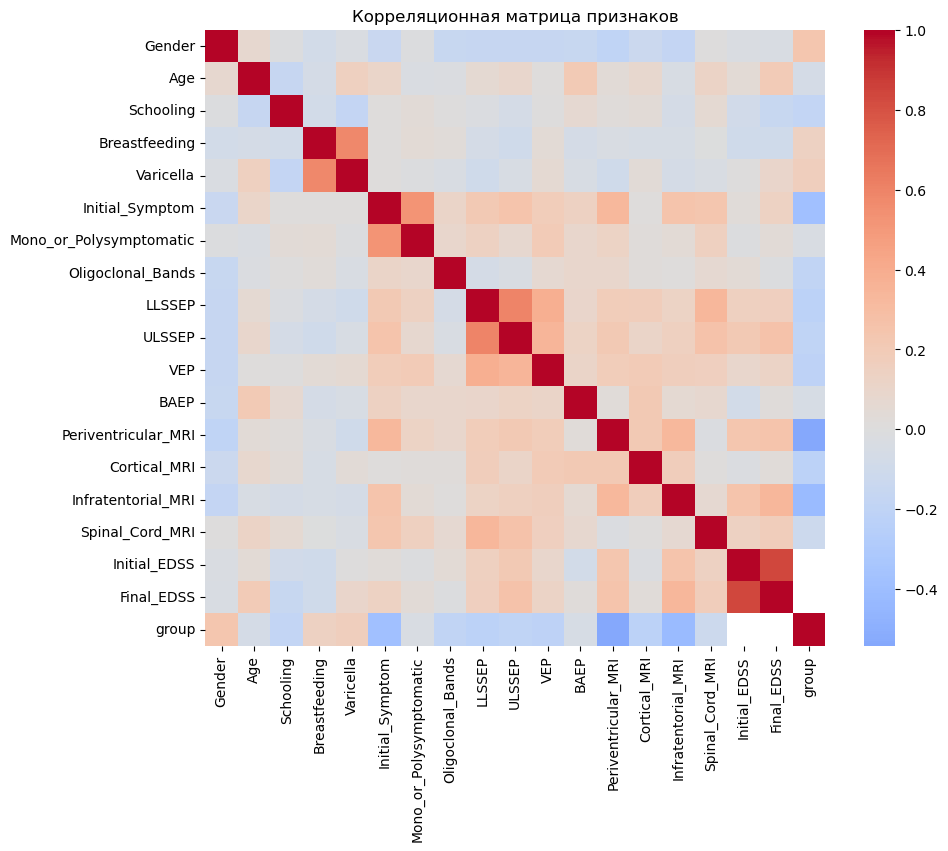

In [107]:
plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Корреляционная матрица признаков")
plt.show()

Явных зависимостей между признаками не наблюдается, чуть сильнее коррелируют начальный и конечный EDSS, МРТ-признаки. EDSS скорее всего и так будет удален при обучении, а вот с МРТ нужно будет смотреть подробнее. В целом, кажется, опасаться мультиколлинеарности не стоит

C:\Users\drser\AppData\Local\Temp\ipykernel_1664\601122997.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=edss_df, x="group", y="Final_EDSS", palette="coolwarm")


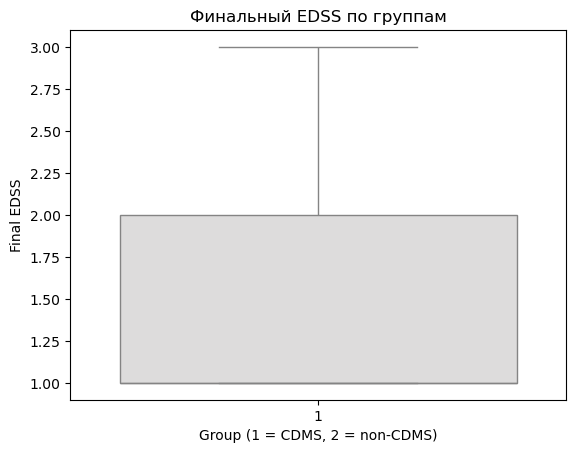

In [112]:
edss_df = df.dropna(subset=["Initial_EDSS", "Final_EDSS"])

plt.figure()
sns.boxplot(data=edss_df, x="group", y="Final_EDSS", palette="coolwarm")
plt.title("Финальный EDSS по группам")
plt.xlabel("Group (1 = CDMS, 2 = non-CDMS)")
plt.ylabel("Final EDSS")
plt.show()

Очевидное - очевидно, среди не больных РС пациентов значений EDSS нет.

## Итог

1. **Тип данных:** преобладают бинарные и категориальные признаки; требуется перекодировка категориальных в числовые.
2. **Пропуски:** большие в EDSS - удалить; остальные можно заполнить модой/медианой.
3. **Классы сбалансированы**, что упрощает выбор метрик.
4. **Влияние МРТ-признаков** подтверждает клиническую значимость — важно сохранить их в данных.
5. **Предобработка:** нормализация числовых признаков, кодирование категориальных, импутация NaN, возможный отбор признаков.